# Market Timing vs Time in the Market in the Long Term

In [260]:
import numpy as np
import pandas as pd

In [261]:
prices=pd.read_csv("STOXX_600_TR_daily.csv", header=0, index_col=0)
prices.head()

,Open,High,Low,Close,Volume,Adjusted
Date,,,,,,
2006-01-02,310.010010,311.410004,310.010010,311.190002,0.0,311.190002
2006-01-03,311.089996,314.320007,311.089996,313.040009,0.0,313.040009
2006-01-04,313.179993,316.140015,313.179993,316.140015,0.0,316.140015
2006-01-05,315.890015,315.950012,314.880005,315.040009,0.0,315.040009
2006-01-06,314.929993,317.100006,314.929993,317.100006,0.0,317.100006


In [262]:
prices["Returns"]=prices["Adjusted"].pct_change(fill_method=None)

In [263]:
prices=prices.ffill(limit=1)
prices=prices.dropna()
prices = prices.drop(columns=["Open", "High", "Low","Close","Volume"])

### Now that we have our Returns column we can move to create the wealth index for the lump sum

In [264]:
money=50000
prices["Lump Sum"] = money * (1 + prices["Returns"]).cumprod()

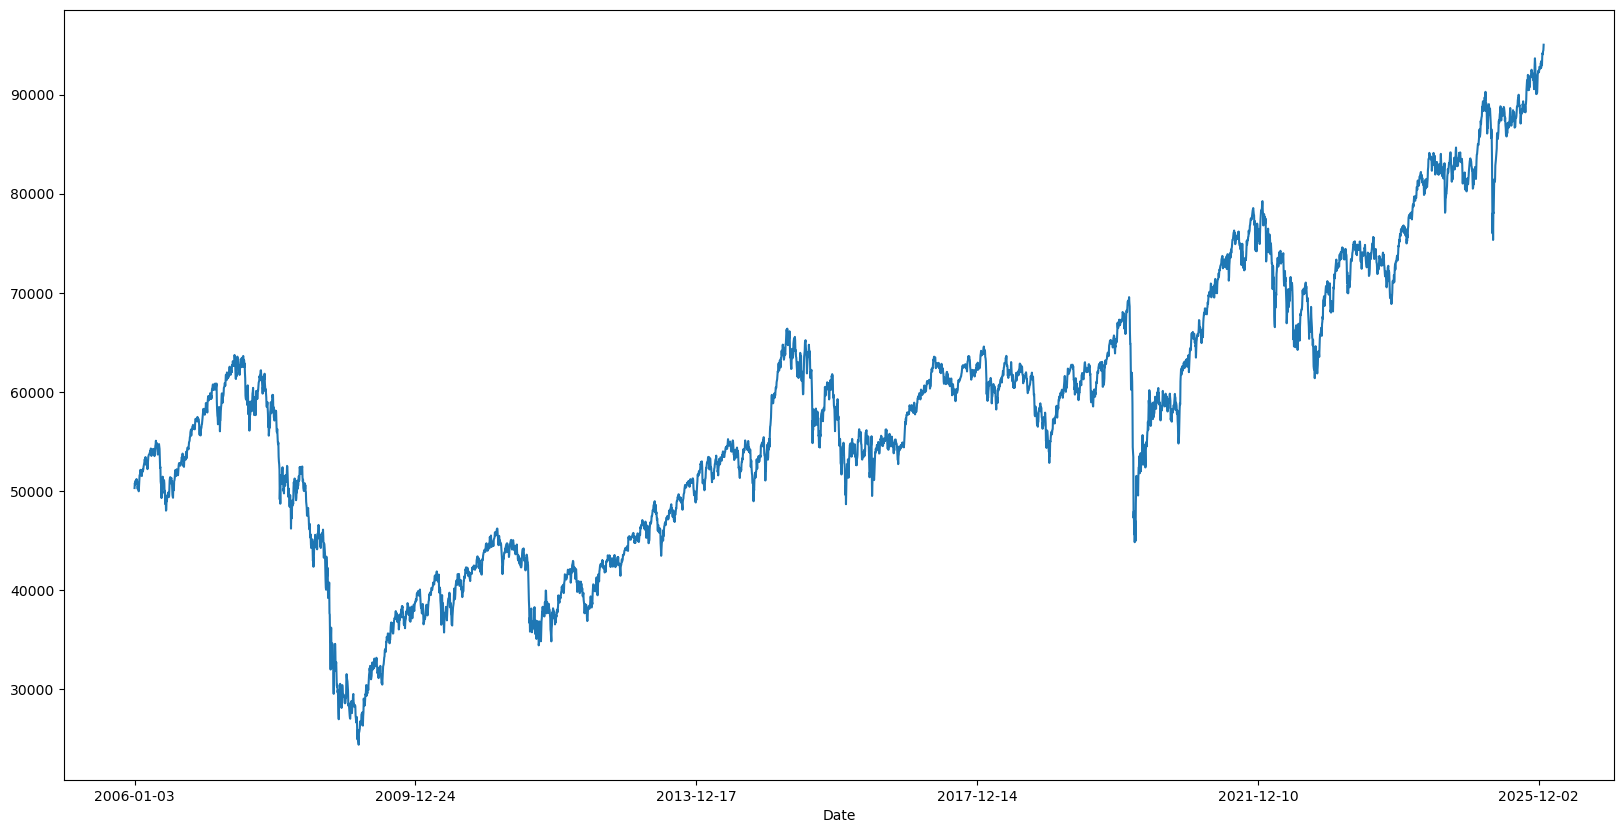

In [265]:
prices["Lump Sum"].plot(figsize=(20,10))
# Comaprison functions for later
def CAGR(wealth):
    return (wealth.iloc[-1] / wealth.iloc[0]) ** (252 / len(wealth)) - 1

def max_drawdown(wealth):
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def ann_vol(returns):
    return returns.std() * np.sqrt(252)

def sharpe(returns, rf=0):
    return (returns.mean() * 252 - rf) / (returns.std() * np.sqrt(252))

In [266]:
# Stats for portfolio lump sum
cagr_lump=CAGR(prices["Lump Sum"])
print("CAGR of Lump Sum Portfolio --> ", cagr_lump*100,"%")
tot_return_lump=(prices["Lump Sum"].iloc[-1] - prices["Lump Sum"].iloc[0])/(prices["Lump Sum"].iloc[0])
print("Total Return of the Lump Sum Portfolio --> ", tot_return_lump*100,"%")
max_dd_lump=max_drawdown(prices["Lump Sum"])
print("Max Drawdown of the Lump Sum Portfolio is --> ", max_dd_lump*100,"%")
print("Minimum Daily Return -->", prices["Lump Sum"].pct_change().min() * 100, "% on", prices["Lump Sum"].pct_change().idxmin())
print("Maximum Daily Return -->", prices["Lump Sum"].pct_change().max() * 100, "% on", prices["Lump Sum"].pct_change().idxmax())
ann_vol_lump=ann_vol(prices["Lump Sum"].pct_change())
print("The annualized volatility of the Lump Sum Portfolio is --> ",ann_vol_lump*100,"%")
print("The time spent in cash is --> 0%")

CAGR of Lump Sum Portfolio -->  3.246708831776801 %
Total Return of the Lump Sum Portfolio -->  88.93521728952543 %
Max Drawdown of the Lump Sum Portfolio is -->  -61.713495254744075 %
Minimum Daily Return --> -11.47762980183309 % on 2020-03-12
Maximum Daily Return --> 9.866908668938423 % on 2008-10-13
The annualized volatility of the Lump Sum Portfolio is -->  18.360054419435084 %
The time spent in cash is --> 0%


## Adding Cash Only adjsuted for Inflation 
This would mean a decrease in the nominal value, while in reality the nominal value would be 50k also on the last day, the only thing that really goes down is the purchasing power, so you could see this as value x of cash on the year y buys at that date the same stuff that that value X would have both in the start of the dataset

In [267]:
inflation=pd.read_csv("ECB_EU_INFLATION.csv", header=0, index_col=0)
inflation=inflation.drop(columns=["TIME PERIOD"])
inflation.columns = ["Values"]
inflation=inflation.dropna()
inflation["Values"]=(-inflation["Values"]/100.0)/12
inflation

,Values
DATE,
1997-01-31,-0.001750
1997-02-28,-0.001500
1997-03-31,-0.001250
1997-04-30,-0.001083
1997-05-31,-0.001167
...,...
2026-02-28,-0.001583
2026-03-31,-0.002167
2026-04-30,-0.002500


<Axes: xlabel='Date'>

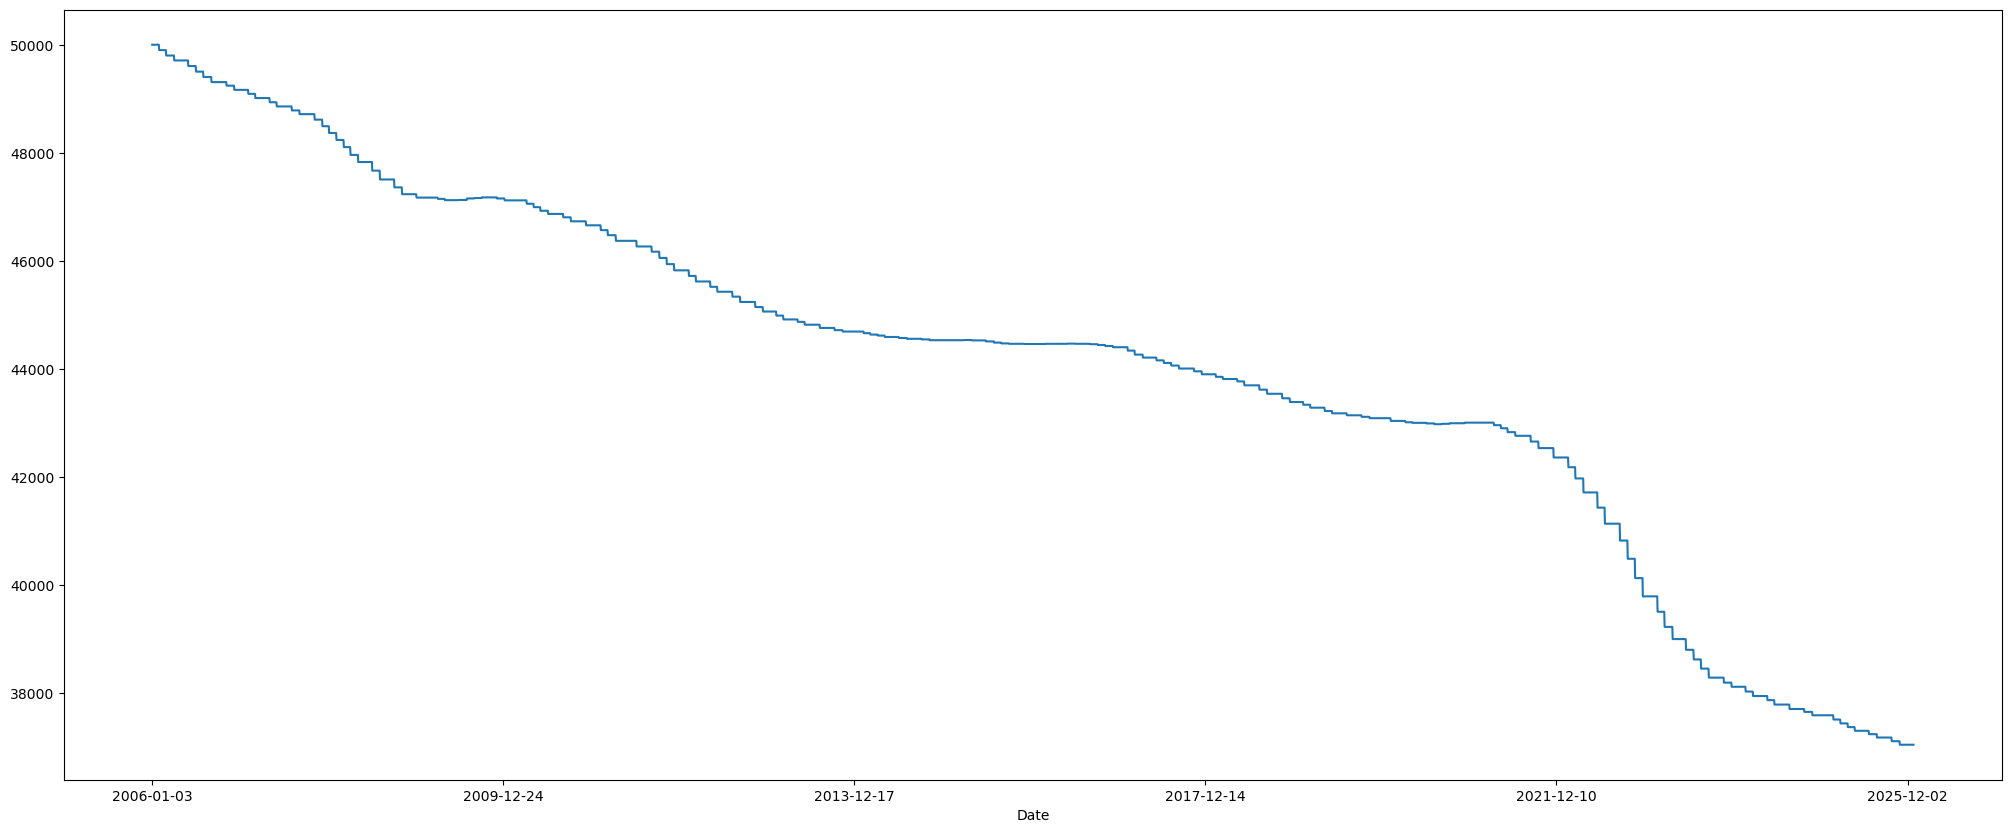

In [268]:
prices["Inflation"]=inflation
prices["Inflation"]=prices["Inflation"].fillna(0)
prices["Cash"] = money * (1 + prices["Inflation"]).cumprod()
prices["Cash"].plot(figsize=(25,10))

In [269]:
# Stats for Cash
cagr_cash=CAGR(prices["Cash"])
print("CAGR of Cash --> ", cagr_cash*100,"%")
tot_return_cash=(prices["Cash"].iloc[-1] - prices["Cash"].iloc[0])/(prices["Cash"].iloc[0])
print("Total Return of Cash --> ", tot_return_cash*100,"%")
max_dd_cash=max_drawdown(prices["Cash"])
print("Max Drawdown of Cash is --> ", max_dd_cash*100,"%")
print("Minimum Daily Return -->", prices["Cash"].pct_change().min() * 100, "% on", prices["Cash"].pct_change().idxmin())
print("Maximum Daily Return -->", prices["Cash"].pct_change().max() * 100, "% on", prices["Cash"].pct_change().idxmax())
ann_vol_cash=ann_vol(prices["Cash"].pct_change())
print("The annualized volatility of Cash is --> ",ann_vol_cash*100,"%")
print("The time spent in cash is --> 100%")

CAGR of Cash -->  -1.4942021606788924 %
Total Return of Cash -->  -25.90197139435375 %
Max Drawdown of Cash is -->  -25.90197139435375 %
Minimum Daily Return --> -0.8833333333333471 % on 2022-10-31
Maximum Daily Return --> 0.05833333333333801 % on 2009-07-31
The annualized volatility of Cash is -->  0.7231631229439797 %
The time spent in cash is --> 100%


## Annual investing.
Investing 2500€ after every trading year (252 days)

<Axes: title={'center': 'Annual Investing Portfolio'}, xlabel='Date'>

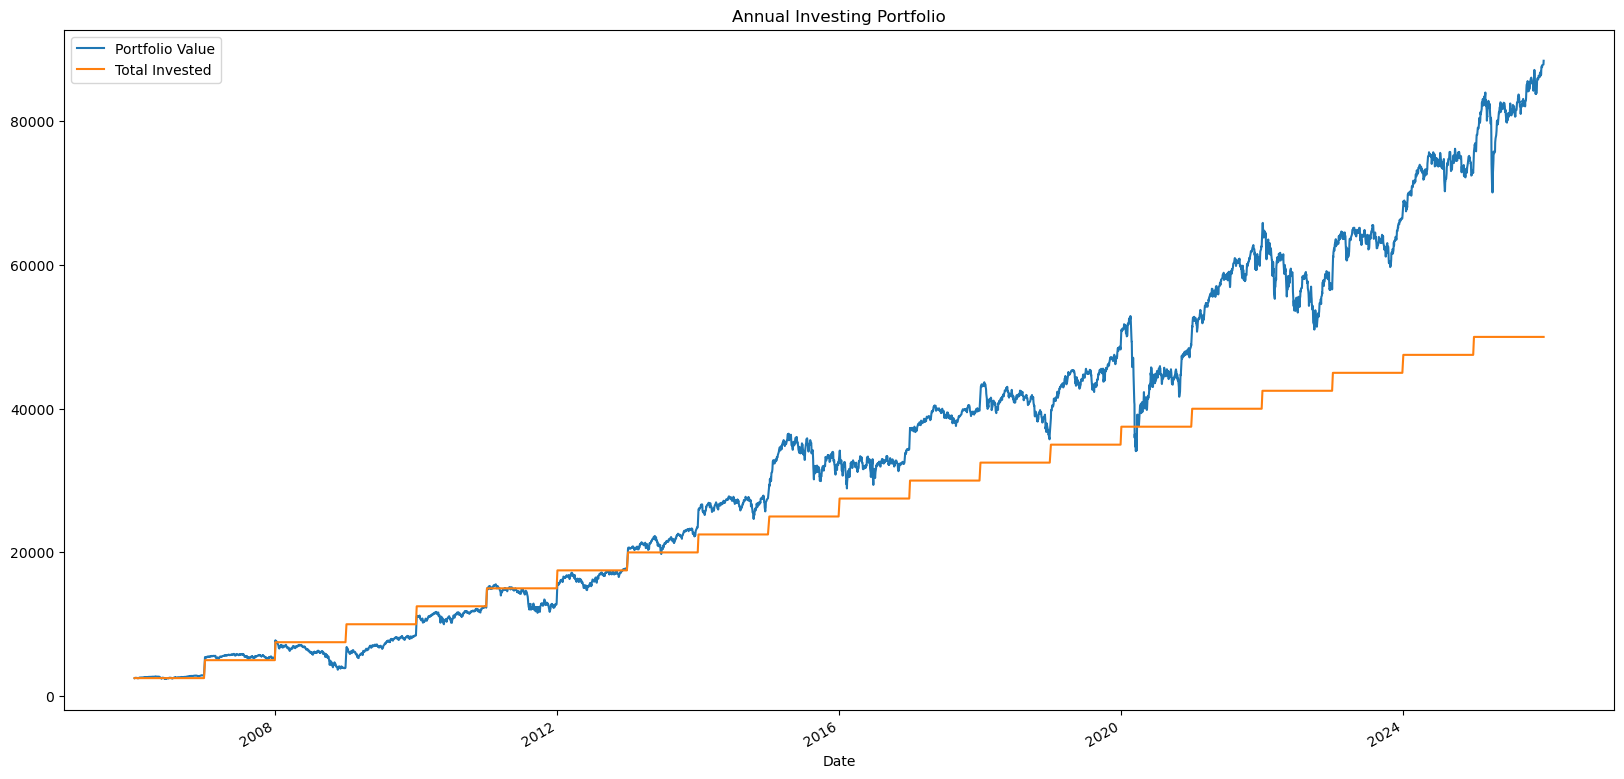

In [271]:
# Annual investing portfolio
prices.index = pd.to_datetime(prices.index)
annual_contribution = 2500
max_invested = 50000

ANNUAL = pd.DataFrame(index=prices.index)

# Copy market returns
ANNUAL["Returns"] = prices["Returns"].fillna(0)

# The strategy begins on day one: no prior-day return exists
ANNUAL.loc[ANNUAL.index[0], "Returns"] = 0.0

# Contributions
ANNUAL["Contribution"] = 0.0

# First trading day of every calendar year, including the first dataset day
first_trading_day_year = (
    ANNUAL.groupby(ANNUAL.index.year)
    .head(1)
    .index
)

ANNUAL.loc[first_trading_day_year, "Contribution"] = annual_contribution

# Never contribute more than €50,000
ANNUAL["Contribution"] = ANNUAL["Contribution"].where(
    ANNUAL["Contribution"].cumsum() <= max_invested,
    0.0
)

# Total capital contributed
ANNUAL["Total Invested"] = ANNUAL["Contribution"].cumsum()

# Market growth
growth = (1 + ANNUAL["Returns"]).cumprod()

# Portfolio value
ANNUAL["Portfolio Value"] = growth * (
    ANNUAL["Contribution"] / growth
).cumsum()

# Contribution-adjusted daily returns
ANNUAL["Adjusted Returns"] = (
    (ANNUAL["Portfolio Value"] - ANNUAL["Contribution"])
    / ANNUAL["Portfolio Value"].shift(1)
    - 1
)

annual_returns = ANNUAL["Adjusted Returns"].dropna()

ANNUAL[["Portfolio Value", "Total Invested"]].plot(
    figsize=(20, 10),
    title="Annual Investing Portfolio"
)

In [278]:

annual_performance = pd.Series(1.0, index=ANNUAL.index)

annual_performance.iloc[1:] = (1 + annual_returns).cumprod().to_numpy()

# Stats for Annual Investing
cagr_annual = CAGR(annual_performance)
print("CAGR of Annual Investing Portfolio --> ", cagr_annual * 100, "%")

tot_return_annual = annual_performance.iloc[-1] - 1
print("Time-Weighted Total Return of Annual Investing Portfolio --> ", tot_return_annual * 100, "%")

max_dd_annual = max_drawdown(annual_performance)
print("Max Drawdown of Annual Investing Portfolio is --> ", max_dd_annual * 100, "%")

print("Minimum Daily Return -->", annual_returns.min() * 100, "% on", annual_returns.idxmin())
print("Maximum Daily Return -->", annual_returns.max() * 100, "% on", annual_returns.idxmax())

ann_vol_annual = ann_vol(annual_returns)
print("The annualized volatility of the Annual Investing Portfolio is --> ", ann_vol_annual * 100, "%")

total_invested = ANNUAL["Total Invested"].iloc[-1]
final_value = ANNUAL["Portfolio Value"].iloc[-1]

capital_gain_annual = (final_value - total_invested) / total_invested

print("The total amount invested is --> €", total_invested)
print("The final portfolio value is --> €", final_value)
print("Return on Total Contributions --> ", capital_gain_annual * 100, "%")

CAGR of Annual Investing Portfolio -->  3.2467088317767345 %
Time-Weighted Total Return of Annual Investing Portfolio -->  88.93521728952372 %
Max Drawdown of Annual Investing Portfolio is -->  -61.71349525474411 %
Minimum Daily Return --> -11.47762980183309 % on 2020-03-12 00:00:00
Maximum Daily Return --> 9.866908668938468 % on 2008-10-13 00:00:00
The annualized volatility of the Annual Investing Portfolio is -->  18.36005441943508 %
The total amount invested is --> € 50000.0
The final portfolio value is --> € 88441.9070449741
Return on Total Contributions -->  76.8838140899482 %


<Axes: xlabel='Date'>

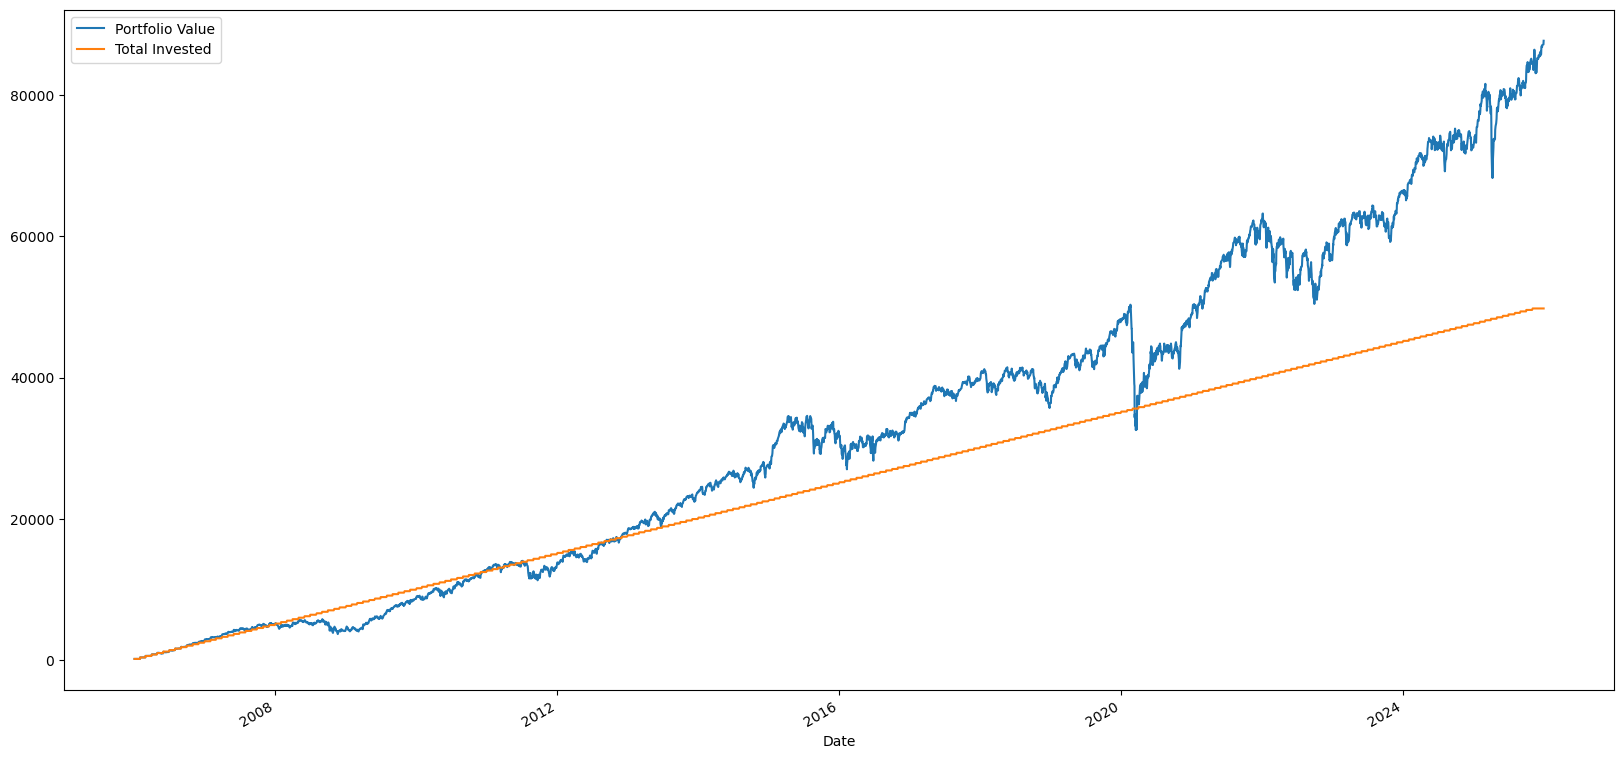

In [273]:
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()
monthly_contribution = 50000 / 240   # €208.33 per month
max_invested = 50000

MONTHLY = pd.DataFrame(index=prices.index)
MONTHLY["Returns"] = prices["Returns"].fillna(0)

MONTHLY["Contribution"] = 0.0

# First trading day of each month
first_trading_day = MONTHLY.groupby(
    [MONTHLY.index.year, MONTHLY.index.month]
).head(1).index

MONTHLY.loc[first_trading_day, "Contribution"] = monthly_contribution

# Prevent total contributions from exceeding €50,000
MONTHLY["Contribution"] = MONTHLY["Contribution"].where(
    MONTHLY["Contribution"].cumsum() <= max_invested,
    0.0
)

MONTHLY["Total Invested"] = MONTHLY["Contribution"].cumsum()

growth = (1 + MONTHLY["Returns"]).cumprod()

MONTHLY["Portfolio Value"] = growth * (
    MONTHLY["Contribution"] / growth
).cumsum()

MONTHLY[[ "Portfolio Value", "Total Invested"]].plot(figsize=(20, 10))

In [274]:
# Stats for Monthly Investing
cagr_monthly = CAGR(monthly_performance)
print("CAGR of Monthly Investing Portfolio --> ", cagr_monthly * 100, "%")

tot_return_monthly = monthly_performance.iloc[-1] - 1

max_dd_monthly = max_drawdown(monthly_performance)
print("Max Drawdown of Monthly Investing Portfolio is --> ", max_dd_monthly * 100, "%")

print("Minimum Daily Return -->", monthly_returns.min() * 100, "% on", monthly_returns.idxmin())
print("Maximum Daily Return -->", monthly_returns.max() * 100, "% on", monthly_returns.idxmax())

ann_vol_monthly = ann_vol(monthly_returns)
print("The annualized volatility of the Monthly Investing Portfolio is --> ", ann_vol_monthly * 100, "%")

total_invested_monthly = MONTHLY["Total Invested"].iloc[-1]
final_value_monthly = MONTHLY["Portfolio Value"].iloc[-1]

capital_gain_monthly = (final_value_monthly - total_invested_monthly) / total_invested_monthly

print("The total amount invested is --> €", total_invested_monthly)
print("The final portfolio value is --> €", final_value_monthly)
print("Return on Total Contributions --> ", capital_gain_monthly * 100, "%")

CAGR of Monthly Investing Portfolio -->  3.196274818746181 %
Max Drawdown of Monthly Investing Portfolio is -->  -61.71349525474403 %
Minimum Daily Return --> -11.47762980183309 % on 2020-03-12 00:00:00
Maximum Daily Return --> 9.866908668938446 % on 2008-10-13 00:00:00
The annualized volatility of the Monthly Investing Portfolio is -->  18.360054419435073 %
The total amount invested is --> € 49791.66666666679
The final portfolio value is --> € 87666.14152363029
Return on Total Contributions -->  76.06589092611897 %


<Axes: xlabel='Date'>

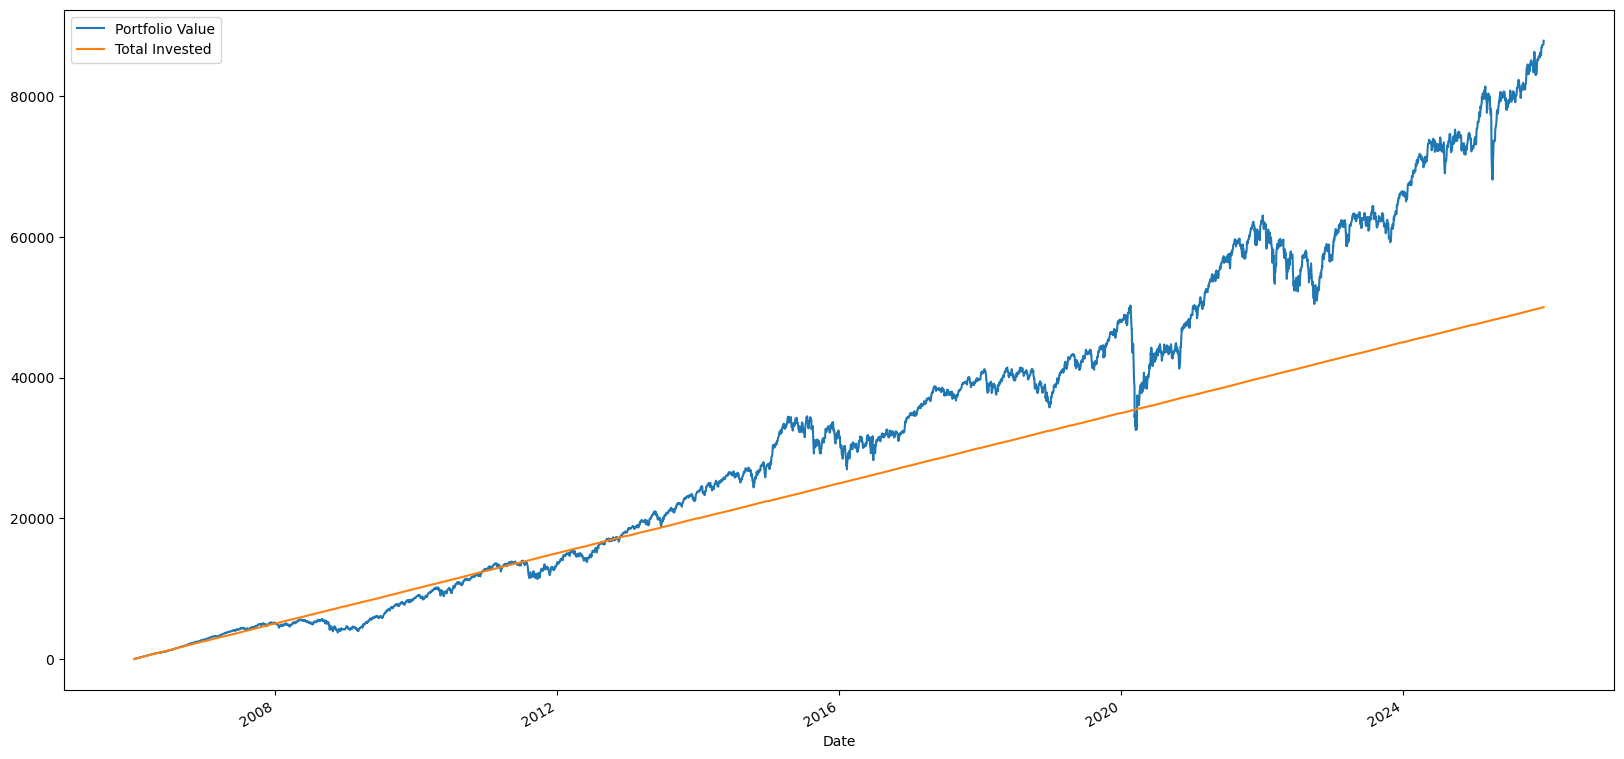

In [279]:
# Daily DCA Portfolio
max_invested = 50000
daily_contribution = max_invested / len(prices)

DAILY = pd.DataFrame(index=prices.index)

# Copy market returns
DAILY["Returns"] = prices["Returns"].fillna(0)

# Divide €50,000 equally across every trading day
DAILY["Contribution"] = daily_contribution

# Ensure the final total is exactly €50,000
DAILY.iloc[-1, DAILY.columns.get_loc("Contribution")] = (
    max_invested - DAILY["Contribution"].iloc[:-1].sum()
)

# Cumulative amount contributed
DAILY["Total Invested"] = DAILY["Contribution"].cumsum()

# Cumulative market growth
growth = (1 + DAILY["Returns"]).cumprod()

# Portfolio value
DAILY["Portfolio Value"] = growth * (
    DAILY["Contribution"] / growth
).cumsum()

DAILY[[ "Portfolio Value", "Total Invested"]].plot(figsize=(20, 10))

In [280]:
# Contribution-adjusted returns for Daily DCA
daily_returns = (
    (DAILY["Portfolio Value"] - DAILY["Contribution"])
    / DAILY["Portfolio Value"].shift(1)
    - 1
).dropna()

daily_performance = (1 + daily_returns).cumprod()


# Stats for Daily DCA
cagr_daily = CAGR(daily_performance)
print("CAGR of Daily DCA Portfolio --> ", cagr_daily * 100, "%")

tot_return_daily = daily_performance.iloc[-1] - 1

max_dd_daily = max_drawdown(daily_performance)
print("Max Drawdown of Daily DCA Portfolio is --> ", max_dd_daily * 100, "%")

print("Minimum Daily Return -->", daily_returns.min() * 100, "% on", daily_returns.idxmin())
print("Maximum Daily Return -->", daily_returns.max() * 100, "% on", daily_returns.idxmax())

ann_vol_daily = ann_vol(daily_returns)
print("The annualized volatility of the Daily DCA Portfolio is --> ", ann_vol_daily * 100, "%")

total_invested_daily = DAILY["Total Invested"].iloc[-1]
final_value_daily = DAILY["Portfolio Value"].iloc[-1]

capital_gain_daily = (
    final_value_daily - total_invested_daily
) / total_invested_daily

print("The total amount invested is --> €", total_invested_daily)
print("The final portfolio value is --> €", final_value_daily)
print("Return on Total Contributions --> ", capital_gain_daily * 100, "%")

CAGR of Daily DCA Portfolio -->  3.196274818745537 %
Max Drawdown of Daily DCA Portfolio is -->  -61.71349525474411 %
Minimum Daily Return --> -11.47762980183311 % on 2020-03-12 00:00:00
Maximum Daily Return --> 9.866908668938446 % on 2008-10-13 00:00:00
The annualized volatility of the Daily DCA Portfolio is -->  18.360054419435077 %
The total amount invested is --> € 50000.000000003754
The final portfolio value is --> € 87918.34084352486
Return on Total Contributions -->  75.83668168703652 %


## Plotting all the simple strategies togheter so far



<Axes: title={'center': 'Investment Strategies Comparison'}, xlabel='Date', ylabel='Portfolio Value (€)'>

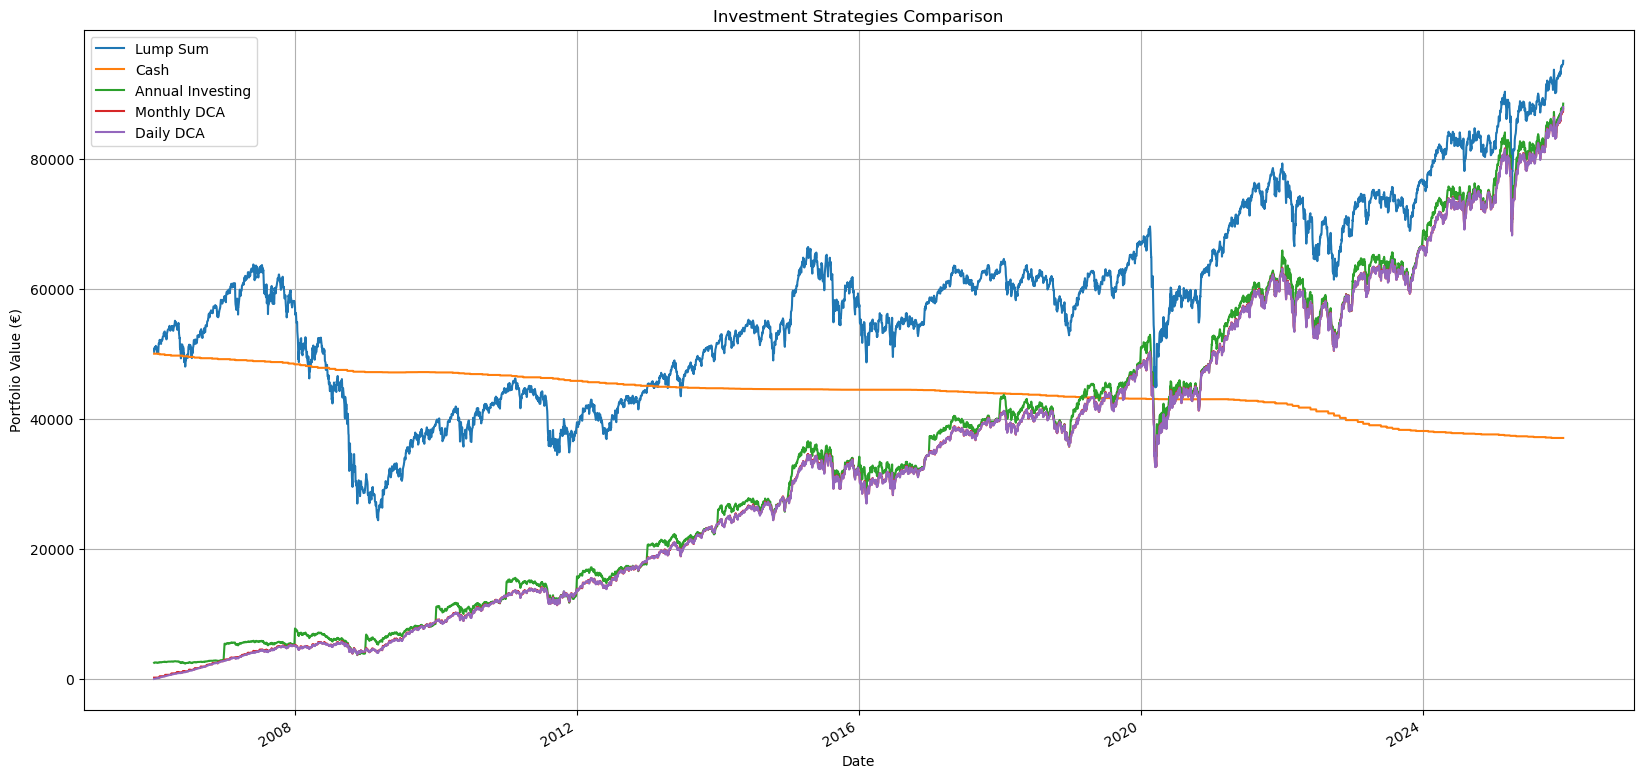

In [281]:
strategies = pd.concat(
    [
        prices["Lump Sum"].rename("Lump Sum"),
        prices["Cash"].rename("Cash"),
        ANNUAL["Portfolio Value"].rename("Annual Investing"),
        MONTHLY["Portfolio Value"].rename("Monthly DCA"),
        DAILY["Portfolio Value"].rename("Daily DCA")
    ],
    axis=1
)

strategies.plot(
    figsize=(20, 10),
    title="Investment Strategies Comparison",
    xlabel="Date",
    ylabel="Portfolio Value (€)",
    grid=True
)